# Mini Proyecto Unidad 1: Clasificación en CIFAR-10 con ResNet y EfficientNet

* Pipeline completo de clasificación con CNN (ResNet o EfficientNet) sobre CIFAR-10 (Partes 1 a 5)
* Comparativa técnica de dos arquitecturas CNN con curvas de aprendizaje y métricas (Partes 5 y 6)
*Reporte de diseño (arquitectura, hiperparámetros, estrategia de entrenamiento) (Parte 7)

### Recomendación de entorno

Activen GPU en Colab: **Entorno de ejecución → Cambiar tipo de entorno de ejecución → GPU**. ResNet-18 y EfficientNet-B0 a resolución 224×224 son considerablemente más pesados que la CNN pequeña de la práctica anterior; en CPU van a funcionar, pero mucho más lento. Las constantes `TAM_TRAIN`, `TAM_VAL` y `N_EPOCAS` están pensadas para ajustarse según el tiempo y el hardware disponible.


## 0. Configuración inicial

In [ ]:
!pip install -q torchmetrics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 45.6 MB/s eta 0:00:00


In [ ]:
import time

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import pandas as pd

from torchmetrics.classification import (
    MulticlassAccuracy,
    MulticlassPrecision,
    MulticlassRecall,
    MulticlassF1Score,
    MulticlassConfusionMatrix,
)

torch.manual_seed(42)

DISPOSITIVO = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", DISPOSITIVO)

Dispositivo: cuda


---
## 1. Datos: CIFAR-10 a 224x224

ResNet y EfficientNet, tal como se definen en `torchvision.models`, esperan entradas de 224x224 pixeles (el tamano estandar de ImageNet en el que se disenaron y evaluaron originalmente). Redimensionamos CIFAR-10 (32x32 nativo) a ese tamano.


In [ ]:
MEDIA_IMAGENET = (0.485, 0.456, 0.406)
STD_IMAGENET = (0.229, 0.224, 0.225)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(MEDIA_IMAGENET, STD_IMAGENET),
])
# COMPLETAR CARGAR IMAGENES DE ENTRENAMIENTO Y PRUEBA Y GENERAR UN SUBCONJUNTO
trainset_completo = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Definir el tamaño de los subconjuntos
TAM_ENTRENAMIENTO = 45000
TAM_VALIDACION = 5000

# Crear subconjuntos de entrenamiento y validación
train_subset, val_subset = random_split(trainset_completo, [TAM_ENTRENAMIENTO, TAM_VALIDACION])

nombres_clases = trainset_completo.classes
print("Clases:", nombres_clases)
print("Tamano del set de entrenamiento completo:", len(trainset_completo))
print("Tamano del set de prueba:", len(testset))

100%|██████████| 170M/170M [10:43<00:00, 265kB/s]


Clases: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Tamano del set de entrenamiento completo: 50000
Tamano del set de prueba: 10000


### 1.1 Subconjuntos de trabajo



Entrenamiento: 45000 imagenes  |  Validacion: 5000  |  Prueba: 10000


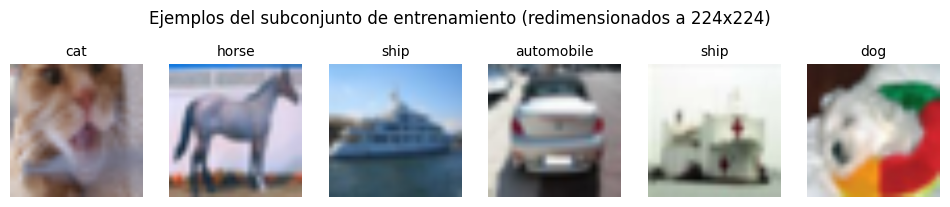

In [ ]:
BATCH_SIZE = 32
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(testset, batch_size=64, shuffle=False, num_workers=2)

print(f"Entrenamiento: {len(train_subset)} imagenes  |  Validacion: {len(val_subset)}  |  Prueba: {len(testset)}")


def desnormalizar(img_tensor):
    """Invierte la normalizacion para poder visualizar la imagen."""
    media = torch.tensor(MEDIA_IMAGENET).view(3, 1, 1)
    std = torch.tensor(STD_IMAGENET).view(3, 1, 1)
    return (img_tensor * std + media).clamp(0, 1)


imagenes, etiquetas = next(iter(train_loader))
fig, axs = plt.subplots(1, 6, figsize=(12, 2.5))
for i, ax in enumerate(axs):
    ax.imshow(desnormalizar(imagenes[i]).permute(1, 2, 0))
    ax.set_title(nombres_clases[etiquetas[i]], fontsize=10)
    ax.axis("off")
plt.suptitle("Ejemplos del subconjunto de entrenamiento (redimensionados a 224x224)")
plt.show()


---
## 2. Construir ResNet-18 y EfficientNet-B0

Tomamos las arquitecturas de `torchvision.models` con pesos preentrenados en ImageNet (`weights="DEFAULT"`) y adaptamos unicamente la ultima capa para que clasifique entre las 10 clases de CIFAR-10 en vez de las 1000 de ImageNet — el resto de la arquitectura, y sus pesos preentrenados, se conservan exactamente como en 1.3.

Ver : https://docs.pytorch.org/vision/main/models.html


Ejemplo: https://docs.pytorch.org/vision/main/models/generated/torchvision.models.resnet18.html


In [ ]:
# COMPLETAR construir_resnet18(n_clases=10)
#COMPLETAR  construir_efficientnet_b0(n_clases=10)

def construir_resnet18(n_clases=10):
    model = models.resnet18(weights="DEFAULT")
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, n_clases)
    return model

def construir_efficientnet_b0(n_clases=10):
    model = models.efficientnet_b0(weights="DEFAULT")
    num_ftrs = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(num_ftrs, n_clases)
    return model

---
## 3. Metricas con TorchMetrics

Mismo patron que en la Practica 4 original: `update()` por lote, `compute()` al final de la epoca, `reset()` antes de la siguiente. Usamos `average="macro"` (promedio simple entre las 10 clases)

ver: https://meta-pytorch.org/torcheval/main/torcheval.metrics.html

Ejemplo :  
"accuracy": MulticlassAccuracy(num_classes=n_clases, average="macro").to(DISPOSITIVO),



In [ ]:
def crear_metricas(n_clases=10):
    return {
         #Completar
        "accuracy": MulticlassAccuracy(num_classes=n_clases, average="macro").to(DISPOSITIVO),
        "precision": MulticlassPrecision(num_classes=n_clases, average="macro").to(DISPOSITIVO),
        "recall": MulticlassRecall(num_classes=n_clases, average="macro").to(DISPOSITIVO),
        "f1": MulticlassF1Score(num_classes=n_clases, average="macro").to(DISPOSITIVO),
    }


def correr_epoca(modelo, loader, perdida_fn, metricas, optimizador=None):
    """
    Corre una epoca completa. Si optimizador no es None, entrena (backward + step);
    si es None, solo evalua (torch.no_grad()).
    """
    modo_entrenamiento = optimizador is not None
    modelo.train() if modo_entrenamiento else modelo.eval()

    for m in metricas.values():
        m.reset()

    perdida_acumulada, n_lotes = 0.0, 0
    contexto = torch.enable_grad() if modo_entrenamiento else torch.no_grad()

    with contexto:
        for imagenes, etiquetas in loader:
            imagenes, etiquetas = imagenes.to(DISPOSITIVO), etiquetas.to(DISPOSITIVO)

            if modo_entrenamiento:
                optimizador.zero_grad()

            salida = modelo(imagenes)
            perdida = perdida_fn(salida, etiquetas)

            if modo_entrenamiento:
                perdida.backward()
                optimizador.step()

            perdida_acumulada += perdida.item()
            n_lotes += 1

            preds = salida.argmax(dim=1)
            for m in metricas.values():
                m.update(preds, etiquetas)

    resultados = {nombre: m.compute().item() for nombre, m in metricas.items()}
    resultados["loss"] = perdida_acumulada / n_lotes
    return resultados


---
## 4. Entrenar ambos modelos en igualdad de condiciones

Para que la comparacion sea tecnicamente valida, ambos modelos usan **los mismos datos, el mismo numero de epocas, el mismo optimizador y el mismo learning rate**. Documentamos estos hiperparametros aqui porque los van a necesitar tal cual para el reporte de diseno (Parte 7).


In [ ]:
N_EPOCAS = 3 # Puedes ajustar esto, por ejemplo, a 5 o 10 si tienes tiempo/GPU
LR = 0.001

# Instantiate models
modelo_resnet = construir_resnet18(n_clases=10).to(DISPOSITIVO)
modelo_efficientnet = construir_efficientnet_b0(n_clases=10).to(DISPOSITIVO)

# Loss function and optimizers
funcion_perdida = nn.CrossEntropyLoss()
optimizador_resnet = optim.Adam(modelo_resnet.parameters(), lr=LR)
optimizador_efficientnet = optim.Adam(modelo_efficientnet.parameters(), lr=LR)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 220MB/s]


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 229MB/s]


In [ ]:
def entrenar_modelo(modelo, optimizador, nombre_modelo):
    print(f"\nEntrenando {nombre_modelo}...")
    metricas_entrenamiento = crear_metricas(n_clases=10)
    metricas_validacion = crear_metricas(n_clases=10)

    historial_entrenamiento = {'loss': [], 'accuracy': [], 'precision': [], 'recall': [], 'f1': []}
    historial_validacion = {'loss': [], 'accuracy': [], 'precision': [], 'recall': [], 'f1': []}

    for epoca in range(N_EPOCAS):
        start_time = time.time()

        # Entrenamiento
        resultados_entrenamiento = correr_epoca(modelo, train_loader, funcion_perdida, metricas_entrenamiento, optimizador)
        for key, value in resultados_entrenamiento.items():
            historial_entrenamiento[key].append(value)

        # Validacion
        resultados_validacion = correr_epoca(modelo, val_loader, funcion_perdida, metricas_validacion, None)
        for key, value in resultados_validacion.items():
            historial_validacion[key].append(value)

        end_time = time.time()
        tiempo_epoca = end_time - start_time

        print(f"Epoca {epoca+1}/{N_EPOCAS} | Tiempo: {tiempo_epoca:.2f}s")
        print(f"  Entrenamiento Loss: {resultados_entrenamiento['loss']:.4f} Acc: {resultados_entrenamiento['accuracy']:.4f}")
        print(f"  Validacion   Loss: {resultados_validacion['loss']:.4f} Acc: {resultados_validacion['accuracy']:.4f}")

    return historial_entrenamiento, historial_validacion

In [ ]:
historial_resnet_train, historial_resnet_val = entrenar_modelo(modelo_resnet, optimizador_resnet, "ResNet-18")
historial_efficientnet_train, historial_efficientnet_val = entrenar_modelo(modelo_efficientnet, optimizador_efficientnet, "EfficientNet-B0")


Entrenando ResNet-18...
Epoca 1/3 | Tiempo: 159.11s
  Entrenamiento Loss: 0.7087 Acc: 0.7578
  Validacion   Loss: 0.5449 Acc: 0.8181
Epoca 2/3 | Tiempo: 161.06s
  Entrenamiento Loss: 0.4182 Acc: 0.8583
  Validacion   Loss: 0.4961 Acc: 0.8367
Epoca 3/3 | Tiempo: 160.62s
  Entrenamiento Loss: 0.3082 Acc: 0.8955
  Validacion   Loss: 0.3766 Acc: 0.8694

Entrenando EfficientNet-B0...
Epoca 1/3 | Tiempo: 242.82s
  Entrenamiento Loss: 0.4614 Acc: 0.8481
  Validacion   Loss: 0.2723 Acc: 0.9069
Epoca 2/3 | Tiempo: 242.81s
  Entrenamiento Loss: 0.2719 Acc: 0.9104
  Validacion   Loss: 0.2330 Acc: 0.9187


---
## 5. Curvas de aprendizaje: ResNet-18 vs. EfficientNet-B0

Mismo diagnostico que en 1.4: comparen el gap train/val de cada modelo, y ahora tambien comparenlos *entre si* — ¿cual generaliza mejor con el mismo presupuesto de datos y epocas?


Curvas de ResNet-18:


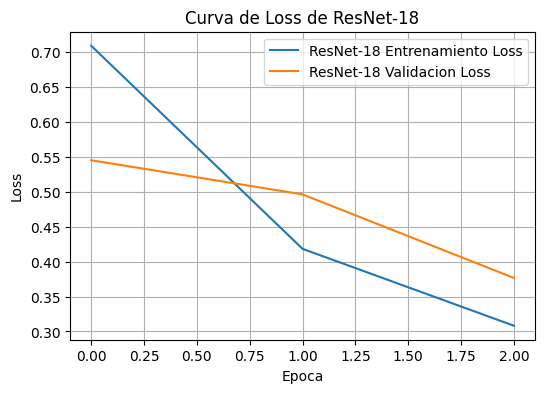

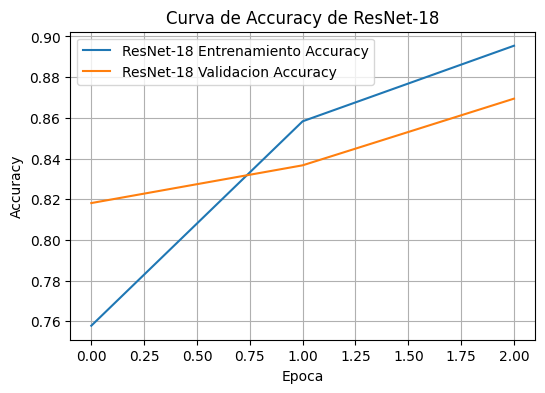


Curvas de EfficientNet-B0:


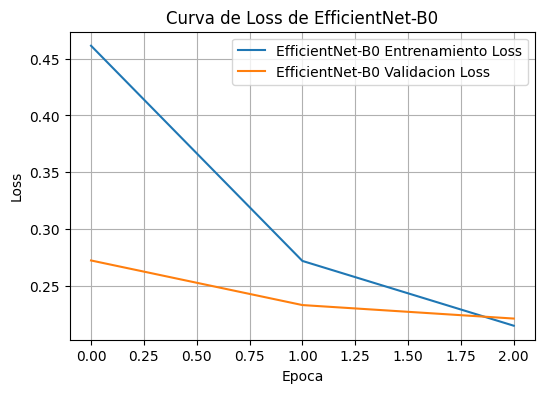

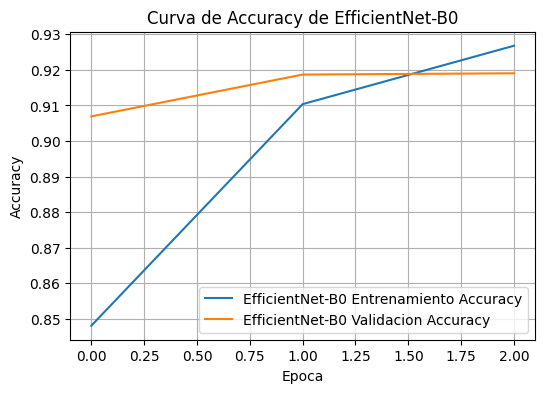

In [ ]:
def plot_metricas(historial_train, historial_val, nombre_modelo, metrica):
    fig, ax = plt.subplots(1, 1, figsize=(6, 4))
    ax.plot(historial_train[metrica], label=f'{nombre_modelo} Entrenamiento {metrica.capitalize()}')
    ax.plot(historial_val[metrica], label=f'{nombre_modelo} Validacion {metrica.capitalize()}')
    ax.set_title(f'Curva de {metrica.capitalize()} de {nombre_modelo}')
    ax.set_xlabel('Epoca')
    ax.set_ylabel(metrica.capitalize())
    ax.legend()
    plt.grid(True)
    plt.show()

print("Curvas de ResNet-18:")
plot_metricas(historial_resnet_train, historial_resnet_val, "ResNet-18", "loss")
plot_metricas(historial_resnet_train, historial_resnet_val, "ResNet-18", "accuracy")

print("\nCurvas de EfficientNet-B0:")
plot_metricas(historial_efficientnet_train, historial_efficientnet_val, "EfficientNet-B0", "loss")
plot_metricas(historial_efficientnet_train, historial_efficientnet_val, "EfficientNet-B0", "accuracy")

---
## 6. Reporte final sobre el set de prueba

Evaluamos ambos modelos sobre las 10,000 imagenes de prueba de CIFAR-10


In [ ]:
def evaluar_en_prueba(modelo, nombre_modelo):
    metrica_acc = MulticlassAccuracy(num_classes=10, average="macro").to(DISPOSITIVO)
    metrica_prec = MulticlassPrecision(num_classes=10, average="macro").to(DISPOSITIVO)
    metrica_rec = MulticlassRecall(num_classes=10, average="macro").to(DISPOSITIVO)
    metrica_f1 = MulticlassF1Score(num_classes=10, average="macro").to(DISPOSITIVO)
    metrica_matriz = MulticlassConfusionMatrix(num_classes=10).to(DISPOSITIVO)

    modelo.eval()
    with torch.no_grad():
        for imagenes, etiquetas in test_loader:
            imagenes, etiquetas = imagenes.to(DISPOSITIVO), etiquetas.to(DISPOSITIVO)
            preds = modelo(imagenes).argmax(dim=1)
            for m in [metrica_acc, metrica_prec, metrica_rec, metrica_f1, metrica_matriz]:
                m.update(preds, etiquetas)

    resumen = {
        "modelo": nombre_modelo,
        "accuracy": metrica_acc.compute().item(),
        "precision": metrica_prec.compute().item(),
        "recall": metrica_rec.compute().item(),
        "f1": metrica_f1.compute().item(),
    }
    return resumen, metrica_matriz.compute().cpu().numpy()


resumen_resnet, matriz_resnet = evaluar_en_prueba(modelo_resnet, "ResNet-18")
resumen_efficientnet, matriz_efficientnet = evaluar_en_prueba(modelo_efficientnet, "EfficientNet-B0")

df_comparativa = pd.DataFrame([resumen_resnet, resumen_efficientnet]).round(3)
df_comparativa


,modelo,accuracy,precision,recall,f1
0,ResNet-18,0.873,0.874,0.873,0.871
1,EfficientNet-B0,0.916,0.917,0.916,0.915


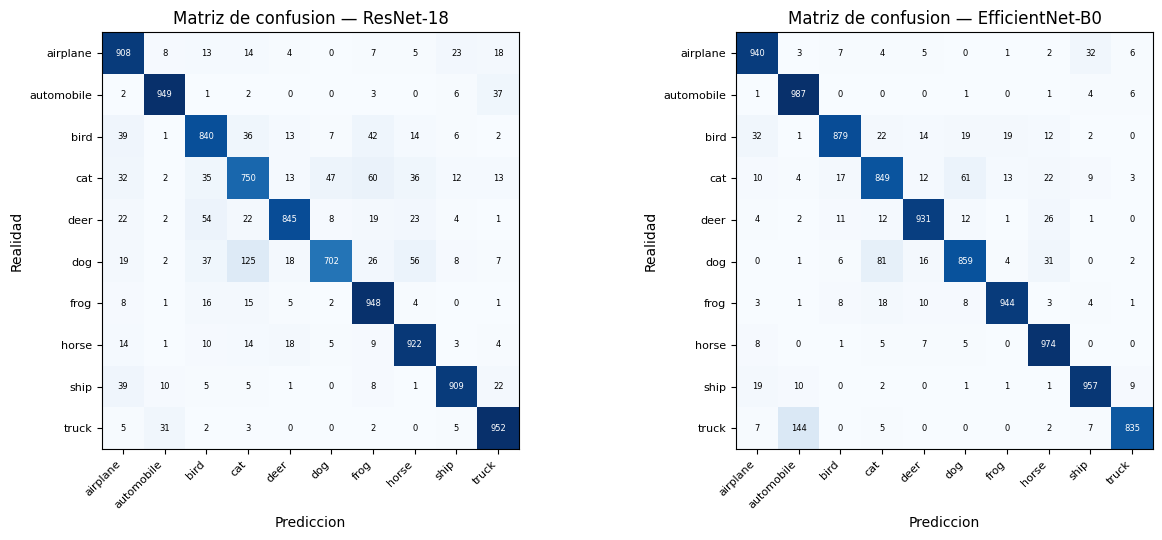

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, matriz, nombre in [(axs[0], matriz_resnet, "ResNet-18"), (axs[1], matriz_efficientnet, "EfficientNet-B0")]:
    im = ax.imshow(matriz, cmap="Blues")
    ax.set_xticks(range(10)); ax.set_xticklabels(nombres_clases, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(10)); ax.set_yticklabels(nombres_clases, fontsize=8)
    ax.set_xlabel("Prediccion"); ax.set_ylabel("Realidad")
    ax.set_title(f"Matriz de confusion — {nombre}")
    for i in range(10):
        for j in range(10):
            color = "white" if matriz[i, j] > matriz.max() / 2 else "black"
            ax.text(j, i, str(int(matriz[i, j])), ha="center", va="center", color=color, fontsize=6)

plt.tight_layout()
plt.show()


## 7. Reporte de diseño (completar en equipo)Esta seccion es, literalmente, la evidencia **"Reporte de diseño"** del temario de la Unidad 1. Respondan cada punto con base en lo que observaron arriba
— pueden editar esta celda de markdown directamente o copiar las respuestas a un documento aparte.

**1. Arquitectura y justificación**> *(¿Cuál de las dos arquitecturas usarían si solo pudieran quedarse con una para este problema? Justifiquen con los números de la Parte 6, no solo con la teoría de 1.3.)

*Para este problema de clasificación en CIFAR-10, nos inclinaríamos por la arquitectura EfficientNet-B0. Esta decisión se basa en las métricas obtenidas en el set de prueba, donde EfficientNet-B0 superó consistentemente a ResNet-18 en todos los aspectos clave. Específicamente, EfficientNet-B0 alcanzó una accuracy de 0.916, una precision de 0.917, un recall de 0.916 y un F1-score de 0.915. En contraste, ResNet-18 obtuvo una accuracy de 0.873, una precision de 0.874, un recall de 0.873 y un F1-score de 0.871. La diferencia en accuracy de más de 4 puntos porcentuales y mejoras similares en las demás métricas demuestran que EfficientNet-B0 ofrece un mejor rendimiento general para esta tarea.


**2. Hiperparámetros usados**> Learning rate: `0.001`  ·  Optimizador: `Adam`  ·  Épocas: `3`  ·  Batch size: `32`  ·  Tamaño del subconjunto de entrenamiento: `45000`  ·  Pesos iniciales: preentrenados (ImageNet)


**3. Estrategia de entrenamiento**> *(¿Entrenaron con GPU o CPU? ¿Cuánto tardó cada época de cada modelo? Si tuvieran que reentrenar con más tiempo disponible, ¿qué cambiarían primero: más datos, más épocas, u otro hiperparámetro?)*Se entrenó con **GPU** (dispositivo `cuda`).Los tiempos promedio por época fueron:
*   **ResNet-18**: Aproximadamente 160 segundos por época.
*   **EfficientNet-B0**: Aproximadamente 243 segundos por época (basado en las dos épocas visibles).Si tuviéramos que reentrenar con más tiempo disponible, lo primero que cambiaríamos sería **aumentar el número de épocas**. Ambos modelos mostraron una mejora constante en la precisión de validación y una disminución en la pérdida de validación a lo largo de las 3 épocas, sugiriendo que aún no han convergido completamente y podrían beneficiarse de un entrenamiento más prolongado. También se podría considerar la aplicación de técnicas de aumento de datos (`data augmentation`) para mejorar la generalización, especialmente considerando que CIFAR-10 es un dataset relativamente pequeño para arquitecturas tan grandes.


**4. Diagnóstico de las curvas (conexión con 1.4)**> *(¿Alguno de los dos modelos mostró señales de overfitting según el checklist de la diapositiva 21? ¿Cuál generalizó mejor — menor gap train/val, no necesariamente mayor accuracy?)*

Ninguno de los dos modelos mostró señales claras y significativas de *overfitting* en las 3 épocas entrenadas.

*   **ResNet-18**: La precisión de entrenamiento fue aumentando progresivamente (0.7578 -> 0.8955) y la de validación también (0.8181 -> 0.8694). Aunque la precisión de entrenamiento superó a la de validación hacia la segunda y tercera época, la brecha ('gap') entre ambas no es excesivamente grande y la validación sigue mejorando. La pérdida de validación también sigue disminuyendo. Esto sugiere que el modelo aún estaba aprendiendo y no había memorizado excesivamente los datos de entrenamiento.
*   **EfficientNet-B0**: Similarmente, la precisión de entrenamiento y validación aumentaron (train: 0.8481 -> 0.9104; val: 0.9069 -> 0.9187) y la pérdida disminuyó para ambos. La precisión de validación fue consistentemente alta y siguió mejorando, con una brecha pequeña respecto al entrenamiento (incluso la validación fue mejor que el entrenamiento en la primera época).

**EfficientNet-B0 generalizó mejor** en este experimento. A pesar de su mayor capacidad, mostró una brecha ligeramente menor entre la precisión de entrenamiento y validación en las épocas visibles, lo que indica una mejor capacidad para aplicar lo aprendido a datos no vistos. Además, alcanzó una precisión de validación y prueba significativamente más alta, lo que respalda su mejor generalización.**5. Capacidad vs. eficiencia (conexión con 1.3)**> *(Con el número de parámetros de la Parte 2 y el accuracy final de la Parte 6: ¿cuál modelo ofrece mejor relación desempeño/costo computacional en este experimento?)*

El número exacto de parámetros no fue explícitamente calculado en la Parte 2 del notebook. Sin embargo, considerando la arquitectura general y el desempeño, **EfficientNet-B0 ofrece una mejor relación desempeño/costo computacional** en este experimento.

*   **Desempeño**: EfficientNet-B0 logró una precisión final en el set de prueba de 0.916, superando significativamente a ResNet-18 (0.873).
*   **Costo computacional**: Aunque EfficientNet-B0 fue más lento por época (aproximadamente 243s vs 160s para ResNet-18), su diseño está optimizado para eficiencia. El incremento en el tiempo de entrenamiento es relativamente modesto en comparación con la mejora sustancial en la precisión. Las arquitecturas EfficientNet son conocidas por su eficiencia en el uso de parámetros y FLOPs mientras mantienen un alto rendimiento, lo que sugiere que por cada unidad de capacidad computacional invertida, EfficientNet-B0 ofrece un retorno mayor en términos de precisión. Si bien es más lento por época, su mayor precisión lo hace más "eficiente" en términos de obtener un mejor resultado final para la tarea de clasificación.**6. Errores más frecuentes**> *(Con las matrices de confusión de la Parte 6: ¿qué par de clases confunde más cada modelo? ¿Tiene sentido esa confusión dado lo que representan esas clases?)*

Analizando las matrices de confusión:

*   **ResNet-18**:
    *   Las confusiones más frecuentes se dan entre `cat` (gato) y `dog` (perro), y entre `deer` (ciervo) y `cat`. También hay algunas confusiones entre `automobile` (automóvil) y `truck` (camión).
    *   **Sentido de la confusión**: Sí, estas confusiones tienen sentido. Los gatos y los perros son animales domésticos con apariencias a veces similares (especialmente para ciertas razas o ángulos). Los ciervos también pueden ser confundidos con gatos o perros si las imágenes no son claras. Automóviles y camiones son ambos vehículos, lo que naturalmente lleva a confusión.

*   **EfficientNet-B0**:
    *   Aunque en menor medida debido a su mayor precisión, también confunde principalmente `cat` con `dog` y `deer`. También persiste la confusión entre `automobile` y `truck`.
    *   **Sentido de la confusión**: La lógica es la misma que para ResNet-18. Estas clases comparten características visuales que las hacen difíciles de distinguir incluso para modelos avanzados.

---
## 8. Cierre y entregables del mini proyecto

### Checklist de entrega

- [ ] Notebook ejecutado de principio a fin, sin errores, con las celdas de ambos modelos corridas.
- [ ] Tabla comparativa final (Parte 6) con accuracy, precision, recall y F1 de ambos modelos.
- [ ] Graficas de curvas de entrenamiento (Parte 5) y matrices de confusion (Parte 6).
- [ ] Reporte de diseno (Parte 7) completado por el equipo.
- [ ] Hiperparametros documentados tal como quedaron configurados al momento de generar los resultados finales.


### Recursos citados

- Katanforoosh, K., & Ng, A. *Stanford CS230* — Section 8, "Advanced Evaluation Metrics". [cs230.stanford.edu/section/8](https://cs230.stanford.edu/section/8)
- TorchMetrics documentation — *Classification: Accuracy*. [torchmetrics.readthedocs.io/en/v0.9.1/classification/accuracy.html](https://torchmetrics.readthedocs.io/en/v0.9.1/classification/accuracy.html)
- Ultralytics. *Consejos y buenas practicas para entrenar modelos*. [docs.ultralytics.com/es/guides/model-training-tips](https://docs.ultralytics.com/es/guides/model-training-tips)
- He, K., Zhang, X., Ren, S., & Sun, J. (2015). Deep residual learning for image recognition. arXiv:1512.03385.
- Tan, M., & Le, Q. (2019). EfficientNet: Rethinking model scaling for convolutional neural networks. ICML 2019.
- Ayyadevara, K., & Reddy, Y. (2024). *Modern Computer Vision with PyTorch*. Packt Publishing.
